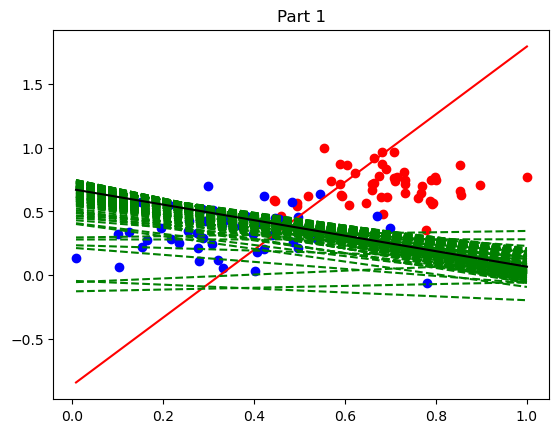

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data-1.csv", header=None)
X = data.iloc[:, 0:2].values   # x1, x2
y = data.iloc[:, 2].values     # labels

# plot points
plt.scatter(X[y==0,0], X[y==0,1], c='red')
plt.scatter(X[y==1,0], X[y==1,1], c='blue')

def step(z):
    if z >= 0:
        return 1
    else:
        return 0

np.random.seed(1)
weights = np.random.randn(2)
bias = np.random.randn()
lr = 5 # learning rate
epochs = 200

# plot initial line in red
x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)
y_vals = -(weights[0]*x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, color='red')

# training
for epoch in range(epochs):
    for i in range(len(X)):
        z = weights[0]*X[i][0] + weights[1]*X[i][1] + bias
        y_hat = step(z)
        error = y[i] - y_hat
        
        # update
        weights[0] = weights[0] + lr * error * X[i][0]
        weights[1] = weights[1] + lr * error * X[i][1]
        bias = bias + lr * error

    # plot dashed green
    y_vals = -(weights[0]*x_vals + bias) / weights[1]
    plt.plot(x_vals, y_vals, color='green', linestyle='--')

# plot final line
y_vals = -(weights[0]*x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, color='black')
plt.title("Part 1")
plt.show()

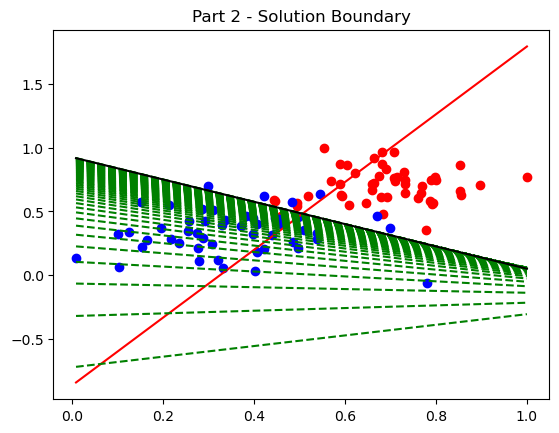

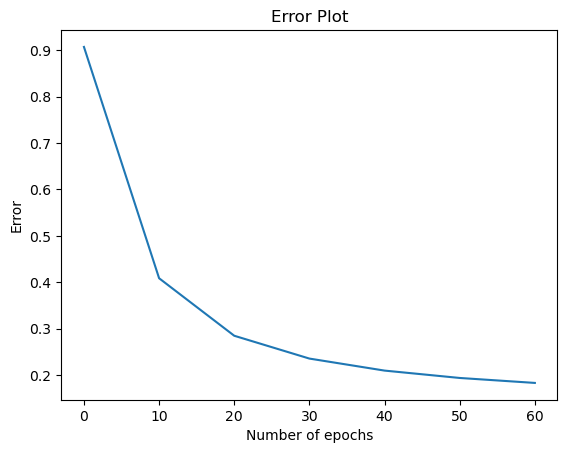

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("data-1.csv", header=None)
X = data.iloc[:, 0:2].values
y = data.iloc[:, 2].values

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

np.random.seed(1)
weights = np.random.randn(2)
bias = np.random.randn()
lr = 0.1
epochs = 65

x_vals = np.linspace(X[:,0].min(), X[:,0].max(), 100)

# plot points
plt.figure(1)
plt.scatter(X[y==0,0], X[y==0,1], c='red')
plt.scatter(X[y==1,0], X[y==1,1], c='blue')

# plot initial line in red
y_vals = -(weights[0]*x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, color='red')

error_history = []

# training
for epoch in range(epochs):
    for i in range(len(X)):
        z = weights[0]*X[i][0] + weights[1]*X[i][1] + bias
        y_hat = sigmoid(z)
        error = y[i] - y_hat
        weights[0] += lr * error * X[i][0]
        weights[1] += lr * error * X[i][1]
        bias += lr * error

    # plot dashed green
    y_vals = -(weights[0]*x_vals + bias) / weights[1]
    plt.plot(x_vals, y_vals, color='green', linestyle='--')

    # log loss every 10 epochs
    if epoch % 10 == 0:
        z_all = weights[0]*X[:,0] + weights[1]*X[:,1] + bias
        y_hat_all = sigmoid(z_all)
        loss = -np.mean(y*np.log(y_hat_all + 1e-9) + (1-y)*np.log(1 - y_hat_all + 1e-9))
        error_history.append((epoch, loss))

# plot final line in black
y_vals = -(weights[0]*x_vals + bias) / weights[1]
plt.plot(x_vals, y_vals, color='black')
plt.title("Part 2 - Solution Boundary")
plt.show()

#error graph
epochs_list = [e[0] for e in error_history]
loss_list = [e[1] for e in error_history]
plt.figure(2)
plt.plot(epochs_list, loss_list)
plt.xlabel("Number of epochs")
plt.ylabel("Error")
plt.title("Error Plot")
plt.show()

In [9]:
!mamba install pandas numpy matplotlib

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 1.269199999999255 seconds
All requested packages already installed.
